# Logistic Regression with Gradient Descent — From Scratch vs. Scikit-Learn

The goal of this notebook is to **understand logistic regression by building it from scratch** with batch gradient descent, and then confirm our result by comparing the decision boundary against **scikit-learn's** `LogisticRegression`.

## The core idea

Logistic regression models the **probability** that a sample belongs to the positive class ($y=1$):

$$P(y=1 \mid \mathbf{x}) = \sigma(z), \qquad z = \mathbf{w}^\top \mathbf{x} + b$$

where $\sigma$ is the **sigmoid** function. We learn the weights $\mathbf{w}$ and bias $b$ by **minimizing the binary cross-entropy (log loss)**:

$$L(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[\, y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\,\Big]$$

Both scikit-learn and our custom implementation are solving this *same* optimization problem — just with different code.

## 1. Generate a toy dataset

We use `make_classification` to create a simple **2-feature, 2-class** dataset so the decision boundary can be drawn as a line in 2D.

Key arguments:
- `n_features=2`, `n_informative=1`, `n_redundant=0` → 2 features, only 1 carries class information
- `class_sep=20` → pushes the two classes far apart, so the boundary is easy to see
- `random_state=41` → reproducible data

In [90]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(
    n_samples=100, n_features=2, n_informative=1, n_redundant=0,
    n_classes=2, n_clusters_per_class=1, random_state=41,
    hypercube=False, class_sep=20,
)

print("X shape:", X.shape)   # (100, 2)
print("y shape:", y.shape)   # (100,)
print("Class counts:", np.bincount(y))

X shape: (100, 2)
y shape: (100,)
Class counts: [50 50]


## 2. Visualize the data

Each point is a sample; color encodes its class label. Because `class_sep` is large, the two classes form two clearly separated groups.

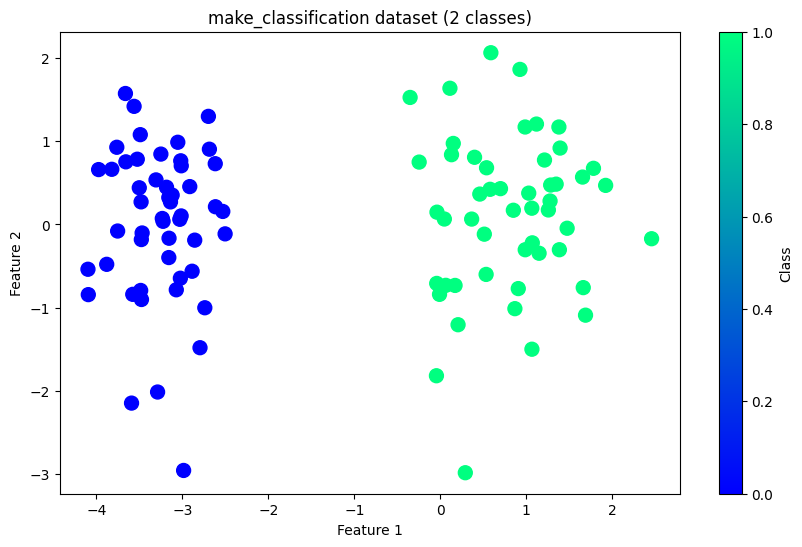

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_classification dataset (2 classes)")
plt.colorbar(label="Class")
plt.show()

## 3. Baseline — scikit-learn's `LogisticRegression`

First we fit the library implementation to use as a **reference / ground truth**.

We want *no regularization* so we can compare against our plain gradient descent (which also has no regularization). In recent scikit-learn versions `penalty=None` is deprecated, so we effectively disable regularization by setting a **very large `C`** (`C` is the inverse of regularization strength — larger `C` = weaker regularization).

The model learns the linear score $z = w_1 x_1 + w_2 x_2 + b$ and predicts class 1 when $\sigma(z) \ge 0.5$, i.e. when $z \ge 0$.

In [92]:
from sklearn.linear_model import LogisticRegression

# C very large  ->  regularization is effectively turned off.
# lbfgs converges cleanly on this well-separated data.
lor = LogisticRegression(penalty=None,solver ='sag')
lor.fit(X, y)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

### Read the learned parameters

`coef_` holds the weights $[w_1, w_2]$ and `intercept_` holds the bias $b$.

In [93]:
print("Weights  (w1, w2):", lor.coef_[0])
print("Intercept (b)   :", lor.intercept_[0])

Weights  (w1, w2): [4.90304527 0.24009425]
Intercept (b)   : 5.847334545206617


## 4. Turn the weights into a decision-boundary line

The decision boundary is the set of points where the model is undecided, i.e. where the score is zero:

$$w_1 x_1 + w_2 x_2 + b = 0$$

Solving for $x_2$ gives the equation of a straight line $x_2 = m\,x_1 + c$:

$$x_2 = -\frac{w_1}{w_2}\,x_1 \;-\; \frac{b}{w_2}$$

So the **slope** is $m = -\dfrac{w_1}{w_2}$ and the **intercept** is $c = -\dfrac{b}{w_2}$.

We compute these from scikit-learn's parameters and build the line points.

In [94]:
# slope and intercept of the sklearn decision boundary
m_sklearn = -lor.coef_[0][0] / lor.coef_[0][1]
b_sklearn = -lor.intercept_[0] / lor.coef_[0][1]

x_line = np.linspace(-3, 3, 100)
y_sklearn = m_sklearn * x_line + b_sklearn

print(f"sklearn boundary:  x2 = {m_sklearn:.3f} * x1 + {b_sklearn:.3f}")

sklearn boundary:  x2 = -20.421 * x1 + -24.354


## 5. Building block — the sigmoid function

The sigmoid squashes any real number into the range $(0, 1)$ so it can be read as a probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- $z \to +\infty \Rightarrow \sigma(z) \to 1$
- $z = 0 \Rightarrow \sigma(z) = 0.5$  (the decision threshold)
- $z \to -\infty \Rightarrow \sigma(z) \to 0$

In [95]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# quick sanity check
print("sigmoid(-10) =", round(sigmoid(-10), 4))
print("sigmoid(0)   =", sigmoid(0))
print("sigmoid(10)  =", round(sigmoid(10), 4))

sigmoid(-10) = 0.0
sigmoid(0)   = 0.5
sigmoid(10)  = 1.0


## 6. Gradient descent from scratch

We now learn the weights ourselves. Instead of a separate bias term, we prepend a **column of 1s** to $X$ so the bias becomes just another weight ($w_0$).

**Prediction:** $\hat{\mathbf{y}} = \sigma(X\mathbf{w})$

**Gradient of the log loss** with respect to the weights:

$$\nabla_{\mathbf{w}} L = -\frac{1}{n}\,X^\top(\mathbf{y} - \hat{\mathbf{y}})$$

**Update rule** (we move *against* the gradient, which flips the sign to `+`):

$$\mathbf{w} := \mathbf{w} + \eta \cdot \frac{1}{n}\,X^\top(\mathbf{y} - \hat{\mathbf{y}})$$

where $\eta$ is the learning rate. We repeat this for a fixed number of iterations.

In [96]:
def gd(X, y, learning_rate=0.5, epochs=5000):
    # add a bias column of 1s  ->  first weight acts as the intercept
    X = np.insert(X, 0, 1, axis=1)
    weights = np.zeros(X.shape[1])

    for i in range(epochs):
        y_hat = sigmoid(np.dot(X, weights))
        # gradient ascent on log-likelihood == gradient descent on log loss
        weights = weights + learning_rate * (np.dot((y - y_hat), X) / X.shape[0])

    # return (feature weights, intercept)
    return weights[1:], weights[0]

### Train and inspect the learned parameters

Compare these with scikit-learn's values above — the direction of the weight vector should match (magnitudes can differ since without regularization the scale is only pinned down by convergence).

In [97]:
coef_, intercept_ = gd(X, y)

print("Custom GD weights  (w1, w2):", coef_)
print("Custom GD intercept (b)    :", intercept_)

Custom GD weights  (w1, w2): [4.83593014 0.21130576]
Custom GD intercept (b)    : 5.828740081963281


## 7. Decision-boundary line for the custom model

Exactly the same derivation as Section 4, using our own weights:

$$m = -\frac{w_1}{w_2}, \qquad c = -\frac{b}{w_2}$$

In [98]:
m_custom = -(coef_[0] / coef_[1])
b_custom = -(intercept_ / coef_[1])

y_custom = m_custom * x_line + b_custom

print(f"custom  boundary:  x2 = {m_custom:.3f} * x1 + {b_custom:.3f}")

custom  boundary:  x2 = -22.886 * x1 + -27.584


## 8. Compare the two decision boundaries

We plot both lines over the data. If our from-scratch gradient descent is correct, the **black** line (custom) should lie almost on top of the **red** line (scikit-learn).

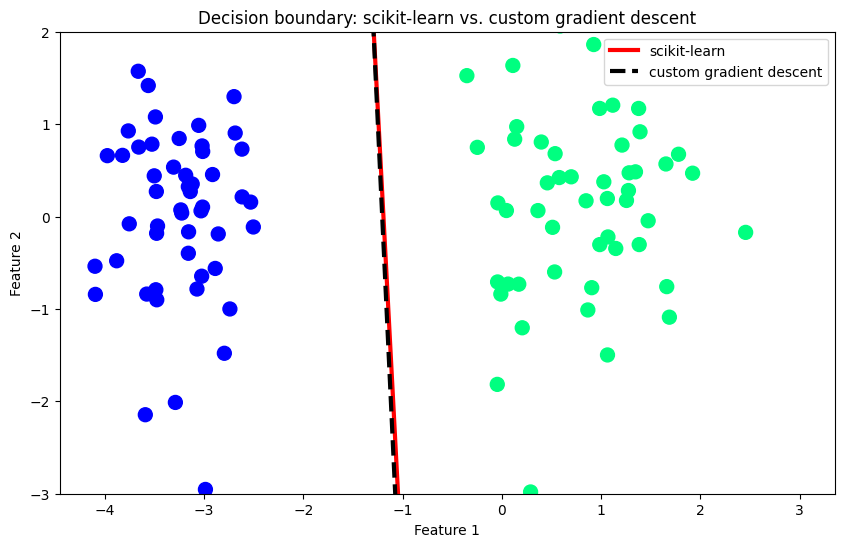

In [99]:
plt.figure(figsize=(10, 6))
plt.plot(x_line, y_sklearn, color='red',   linewidth=3, label='scikit-learn')
plt.plot(x_line, y_custom,  color='black', linewidth=3, linestyle='--', label='custom gradient descent')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary: scikit-learn vs. custom gradient descent")
plt.ylim(-3, 2)
plt.legend()
plt.show()

## Appendix — why we add a column of 1s

Inside `gd` we call `np.insert(X, 0, 1, axis=1)`. This inserts a constant `1` as the **first column** of every row. That lets the bias $b$ be treated as an ordinary weight $w_0$ multiplying this constant feature, so a single dot product handles both weights and bias:

$$z = w_0 \cdot 1 + w_1 x_1 + w_2 x_2$$

The cells below show the trick and the resulting weight-vector shape.

In [100]:
X_bias = np.insert(X, 0, 1, axis=1)
print("Original X shape:", X.shape)
print("With bias column:", X_bias.shape)
X_bias[:5]   # first 5 rows: notice the leading 1

Original X shape: (100, 2)
With bias column: (100, 3)


array([[ 1.        ,  0.51123145, -0.11697552],
       [ 1.        ,  0.06316371, -0.73115232],
       [ 1.        , -0.0425064 , -0.7081059 ],
       [ 1.        , -3.2891569 , -2.01199214],
       [ 1.        ,  0.1111445 ,  1.63493163]])

In [101]:
# one weight per column of X_bias  ->  w0 (bias), w1, w2
print("Initial weights:", np.zeros(X_bias.shape[1]))

Initial weights: [0. 0. 0.]
